## Run a pipeline

### Minimal Pipeline Execution: Runs in just **3 lines of code**

```python
from paidiverpy.pipeline import Pipeline
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()
```

### This is the configuration file:


```yaml
general:
  sample_data: "benthic_ifdo"
  output_path: "./output"
  n_jobs: 8
  sampling:
    - mode: "fixed"
      params:
        value: 5
  convert:
    - mode: "bits"
      params:
        output_bits: 8
steps:
  - colour:
      name: "colour_correction"
      mode: "grayscale"

  - sampling:
      name: "datetime"
      mode: "datetime"
      params:
        min: "2016-05-11 04:14:00"
        max: "2016-05-11 09:27:00"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "sharpen"
      mode: "sharpen"
      params:
        alpha: 1.5
        beta: -0.5

  - colour:
      name: "contrast"
      mode: "contrast"
```

### Sample data

This configuration file uses a part of our example data:

```yaml
general:
  sample_data: "benthic_ifdo"
```

In this case, it will download the data automatically. But you can also do it manually:

In [1]:
from paidiverpy.utils.data import PaidiverpyData

data = PaidiverpyData()
data.load("benthic_ifdo")

{'input_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/images',
 'metadata_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/metadata/metadata_benthic_ifdo.json',
 'metadata_type': 'IFDO',
 'image_open_args': 'JPG'}

## Running the code

In [2]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

In [3]:
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")

In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [5]:
# See the pipeline steps in json format
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 20,
                    "raise_error": false
                },
                "mode": "fixed"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "datetime",
            "step_name": "sampling",
            "test": false,
            "params": {
                "min": "2018-06-11 04:14:00",
                "max": "2018-06-11 04:20:00",
                "raise_error": false
            },
            "mode": "datetime"
        },
        {
            "name": "overlapping",
            "step_name": "sampling",
            "test": false,
            "params": {
                "omega": 57.0,
                "theta": 40.0,
                "threshold": 0.5,
                "camera_distance": 1.12,
                "raise_error": false
            },
            "mode": "overlapping"
        },
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "sigma": 1.0,
                "raise_error": false
            },
            "mode": "gaussian_blur"
        },
        {
            "name": "sharpen",
            "step_name": "colour",
            "test": false,
            "params": {
                "alpha": 1.5,
                "beta": -0.5,
                "raise_error": false
            },
            "mode": "sharpen"
        },
        {
            "name": "contrast",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "clahe",
                "clip_limit": 0.01,
                "gamma_value": 0.5,
                "raise_error": false
            },
            "mode": "contrast"
        }
    ]
}

In [6]:
pipeline.metadata

,ID,image-filename,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,speed_of_sound_m_s,temperature_c,positioning_ok,attitude_ok,depth_ok,altitude_ok,X,phototime,flag,point
0,430.0,20180611041421.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:21,2.828427,FLASH,...,1545.388,1.5059,1,1,1,1,NaN,2018-06-11 04:14:21,0,POINT (-153.60531587 11.25172554)
1,431.0,20180611041431.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:31,2.828427,FLASH,...,1545.447,1.5236,1,1,1,1,NaN,2018-06-11 04:14:31,0,POINT (-153.60531372 11.25171832)
2,432.0,20180611041441.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:41,2.828427,FLASH,...,1545.452,1.5234,1,1,1,1,NaN,2018-06-11 04:14:41,0,POINT (-153.60531259 11.2517135)
3,433.0,20180611041451.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:51,2.828427,FLASH,...,1545.363,1.4911,1,1,1,1,NaN,2018-06-11 04:14:51,0,POINT (-153.60531313 11.25170837)
4,434.0,20180611041501.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:01,2.828427,FLASH,...,1545.324,1.4747,1,1,1,1,NaN,2018-06-11 04:15:01,0,POINT (-153.60531414 11.25170299)
5,435.0,20180611041511.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:11,2.828427,FLASH,...,1545.298,1.4635,1,1,1,1,NaN,2018-06-11 04:15:11,0,POINT (-153.60531664 11.25169768)
6,436.0,20180611041521.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:21,2.828427,FLASH,...,1545.315,1.4697,1,1,1,1,NaN,2018-06-11 04:15:21,0,POINT (-153.6053176 11.25169125)
7,437.0,20180611041531.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:31,2.828427,FLASH,...,1545.326,1.4727,1,1,1,1,NaN,2018-06-11 04:15:31,0,POINT (-153.60532046 11.25168357)
8,438.0,20180611041541.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:41,2.828427,FLASH,...,1545.266,1.4532,1,1,1,1,NaN,2018-06-11 04:15:41,0,POINT (-153.60532129 11.25167559)
9,439.0,20180611041551.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:51,2.828427,FLASH,...,1545.263,1.4512,1,1,1,1,NaN,2018-06-11 04:15:51,0,POINT (-153.60532147 11.25166737)


In [7]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Running step 0: raw - OpenLayer
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Number of images to be removed: 29. Total number of images: 49


Open Images: 100%|████████████████████████████████| 20/20 [00:00<00:00, 1084.77it/s]

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Running step 1: colour_correction - ColourLayer



Processing images: 100%|█████████████████████████| 20/20 [00:00<00:00, 36856.80it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Step 1 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Running step 2: datetime - SamplingLayer
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Number of images to be removed: 5. Total number of images: 20
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Step 2 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Running step 3: overlapping - SamplingLayer
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Number of images to be removed: 7. Total number of images: 15
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Step 3 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Running step 4: colour_correction - ColourLayer


...

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Step 4 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:20 | Running step 5: sharpen - ColourLayer



Processing images: 100%|████████████████████████████| 8/8 [00:00<00:00, 2516.27it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:21 | Step 5 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:21 | Running step 6: contrast - ColourLayer


Processing images: 100%|█████████████████████████████| 8/8 [00:00<00:00, 175.95it/s]

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:21 | Step 6 completed


In [8]:
pipeline.metadata

,image-filename,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,TRcornerlong,TRcornerlat,TLcornerlong,TLcornerlat,BLcornerlong,BLcornerlat,BRcornerlong,BRcornerlat,overlap,polygon_m
0,20180611041441.png,432.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:41,2.828427,FLASH,...,-153.605304,11.251701,-153.605304,11.251726,-153.605321,11.251726,-153.605321,11.251701,0,POLYGON ((-153.60530396770184 11.2517005672041...
1,20180611041451.png,433.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:51,2.828427,FLASH,...,-153.605305,11.251695,-153.605304,11.251721,-153.605322,11.251721,-153.605322,11.251696,1,POLYGON ((-153.60530450358652 11.2516954398786...
2,20180611041501.png,434.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:01,2.828427,FLASH,...,-153.605305,11.251690,-153.605305,11.251716,-153.605323,11.251716,-153.605323,11.251690,1,POLYGON ((-153.60532287038686 11.2516901280594...
3,20180611041551.png,439.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:51,2.828427,FLASH,...,-153.605313,11.251654,-153.605313,11.251680,-153.605330,11.251680,-153.605330,11.251655,0,POLYGON ((-153.60531287424553 11.2516544199985...
4,20180611041621.png,442.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:21,2.828427,FLASH,...,-153.605313,11.251636,-153.605312,11.251662,-153.605330,11.251663,-153.605331,11.251636,0,POLYGON ((-153.60531250603074 11.2516357117654...
5,20180611041631.png,443.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:31,2.828427,FLASH,...,-153.605312,11.251634,-153.605312,11.251659,-153.605329,11.251660,-153.605330,11.251634,1,POLYGON ((-153.60531203486076 11.2516336560737...
6,20180611041641.png,444.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:41,2.828427,FLASH,...,-153.605312,11.251629,-153.605311,11.251655,-153.605329,11.251655,-153.605329,11.251629,1,POLYGON ((-153.60531157256716 11.2516293035685...
7,20180611041701.png,446.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:01,2.828427,FLASH,...,-153.605311,11.251621,-153.605311,11.251647,-153.605329,11.251647,-153.605329,11.251622,0,POLYGON ((-153.60531148160254 11.2516213159115...
8,20180611041721.png,448.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:21,2.828427,FLASH,...,-153.605312,11.251617,-153.605311,11.251643,-153.605329,11.251643,-153.605329,11.251617,1,POLYGON ((-153.6053115481469 11.25161685953249...
9,20180611041731.png,449.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:31,2.828427,FLASH,...,-153.605309,11.251616,-153.605309,11.251642,-153.605327,11.251643,-153.605328,11.251616,1,POLYGON ((-153.60530948504496 11.2516156522718...


Step: raw
Image: [[[177 188 165 255]
  [177 188 164 255]
  [177 188 164 255]
  ...
  [209 206 164 255]
  [211 207 165 255]
  [211 208 165 255]]

 [[180 188 165 255]
  [178 187 164 255]
  [179 187 164 255]
  ...
  [211 207 166 255]
  [211 207 165 255]
  [210 207 167 255]]

 [[178 188 165 255]
  [179 188 167 255]
  [180 188 165 255]
  ...
  [211 207 166 255]
  [214 208 165 255]
  [212 208 170 255]]

 ...

 [[198 198 172 255]
  [199 199 173 255]
  [199 197 171 255]
  ...
  [213 207 170 255]
  [213 209 171 255]
  [213 208 170 255]]

 [[197 196 172 255]
  [197 197 171 255]
  [199 196 170 255]
  ...
  [213 208 170 255]
  [212 207 168 255]
  [214 209 172 255]]

 [[196 197 172 255]
  [197 195 171 255]
  [196 195 171 255]
  ...
  [212 207 168 255]
  [213 207 171 255]
  [213 208 171 255]]]
Image: [[[196 203 175 255]
  [198 203 176 255]
  [199 203 176 255]
  ...
  [210 206 166 255]
  [211 208 165 255]
  [211 208 167 255]]

 [[200 203 179 255]
  [198 202 176 255]
  [199 202 178 255]
  ...
  [211 208 167 255]
  [211 207 167 255]
  [213 208 170 255]]

 [[200 205 179 255]
  [201 204 179 255]
  [199 202 176 255]
  ...
  [213 208 168 255]
  [210 207 169 255]
  [213 208 170 255]]

 ...

 [[198 198 171 255]
  [199 198 174 255]
  [202 200 173 255]
  ...
  [211 208 172 255]
  [214 210 174 255]
  [213 209 175 255]]

 [[197 197 174 255]
  [198 198 174 255]
  [199 196 171 255]
  ...
  [213 209 173 255]
  [214 209 174 255]
  [214 209 174 255]]

 [[196 197 173 255]
  [198 196 172 255]
  [199 197 171 255]
  ...
  [211 207 172 255]
  [214 210 173 255]
  [214 209 176 255]]]
Image: [[[192 200 171 255]
  [191 198 172 255]
  [191 199 170 255]
  ...
  [200 198 158 255]
  [201 199 160 255]
  [202 200 161 255]]

 [[192 200 174 255]
  [191 200 174 255]
  [192 200 174 255]
  ...
  [201 199 160 255]
  [203 200 162 255]
  [200 199 160 255]]

 [[193 199 174 255]
  [192 199 173 255]
  [195 200 176 255]
  ...
  [202 199 160 255]
  [201 200 161 255]
  [202 198 160 255]]

 ...

 [[190 192 168 255]
  [191 193 169 255]
  [197 194 168 255]
  ...
  [204 202 168 255]
  [207 203 169 255]
  [208 205 171 255]]

 [[191 192 167 255]
  [192 191 169 255]
  [193 193 168 255]
  ...
  [205 202 167 255]
  [206 203 169 255]
  [206 203 170 255]]

 [[190 191 169 255]
  [190 191 168 255]
  [192 191 166 255]
  ...
  [206 202 169 255]
  [205 202 169 255]
  [208 203 170 255]]]
Image: [[[184 197 179 255]
  [183 197 178 255]
  [181 196 178 255]
  ...
  [202 207 173 255]
  [204 207 174 255]
  [202 207 174 255]]

 [[179 195 178 255]
  [182 196 178 255]
  [183 195 179 255]
  ...
  [204 206 174 255]
  [203 207 176 255]
  [205 207 175 255]]

 [[181 195 180 255]
  [185 197 182 255]
  [185 197 182 255]
  ...
  [202 207 175 255]
  [204 207 175 255]
  [204 207 177 255]]

 ...

 [[188 194 173 255]
  [187 193 175 255]
  [191 195 174 255]
  ...
  [196 199 171 255]
  [194 197 174 255]
  [195 198 174 255]]

 [[185 192 174 255]
  [188 192 173 255]
  [192 192 175 255]
  ...
  [194 197 171 255]
  [195 198 174 255]
  [194 198 173 255]]

 [[187 193 175 255]
  [190 192 173 255]
  [190 194 172 255]
  ...
  [194 197 170 255]
  [194 196 173 255]
  [194 198 174 255]]]
Image: [[[185 197 179 255]
  [183 196 179 255]
  [187 198 177 255]
  ...
  [191 201 174 255]
  [193 204 175 255]
  [192 203 174 255]]

 [[184 197 178 255]
  [182 194 178 255]
  [184 197 179 255]
  ...
  [195 203 174 255]
  [192 201 175 255]
  [190 202 176 255]]

 [[184 198 180 255]
  [185 197 180 255]
  [184 195 180 255]
  ...
  [194 204 177 255]
  [192 202 176 255]
  [192 202 176 255]]

 ...

 [[185 193 180 255]
  [186 194 178 255]
  [190 196 178 255]
  ...
  [204 207 183 255]
  [207 208 186 255]
  [202 207 183 255]]

 [[185 192 177 255]
  [189 195 180 255]
  [192 194 178 255]
  ...
  [203 206 183 255]
  [205 207 184 255]
  [205 207 184 255]]

 [[186 194 178 255]
  [189 195 179 255]
  [190 193 178 255]
  ...
  [204 207 182 255]
  [203 207 183 255]
  [203 207 186 255]]]
Image: [[[169 185 169 255]
  [167 184 170 255]
  [167 182 168 255]
  ...
  [165 182 1
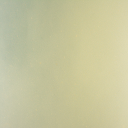
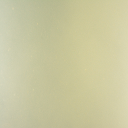
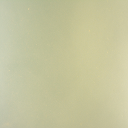
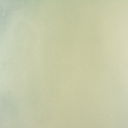
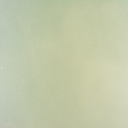
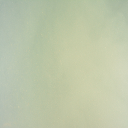
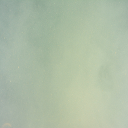
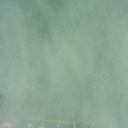
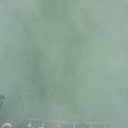
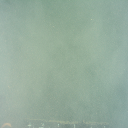
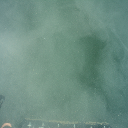
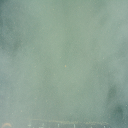
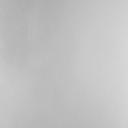
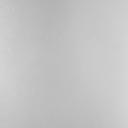
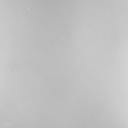
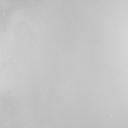
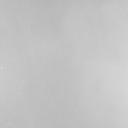
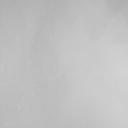
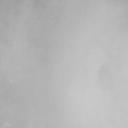
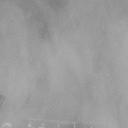
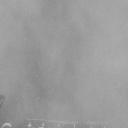
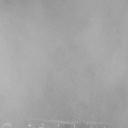
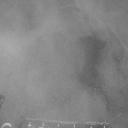
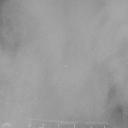
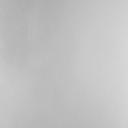
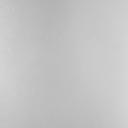
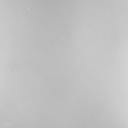
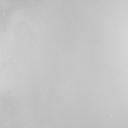
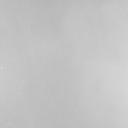
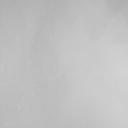
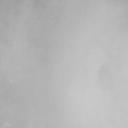
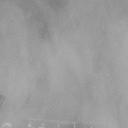
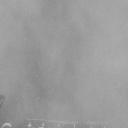
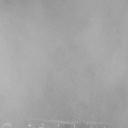
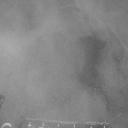
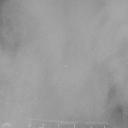
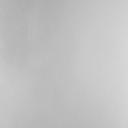
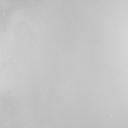
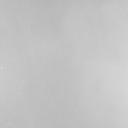
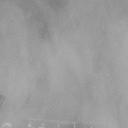
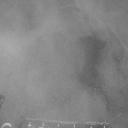
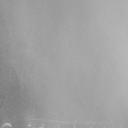
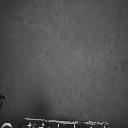
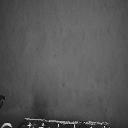
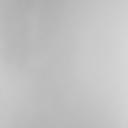
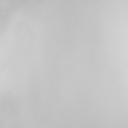
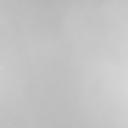
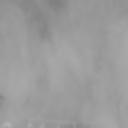
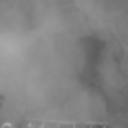
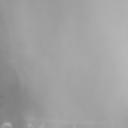
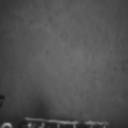
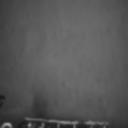
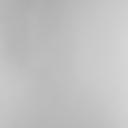
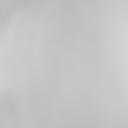
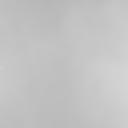
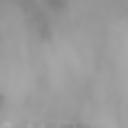
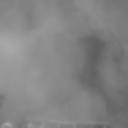
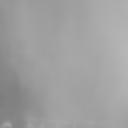
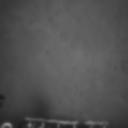
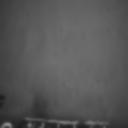
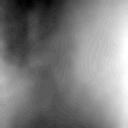
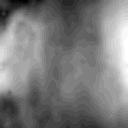
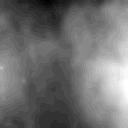
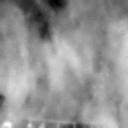
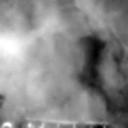
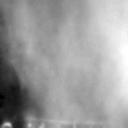
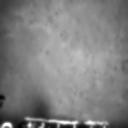
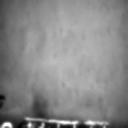

In [9]:
# See the images output
pipeline.images


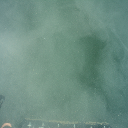
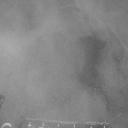
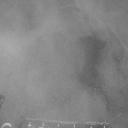

In [10]:
pipeline.images.show(image_number=10)

# Export Images to file

In [11]:
pipeline.save_images(image_format="png")

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:25 | Saving images from step: last
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:25 | Saving images
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:29:25 | Images are saved to: output
